In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential

## Data Generation: Sine Curves

Generate **10,000 sine curves** of the form:

$$
x(t) = A \cdot \sin(\omega t + \phi)
$$

where the parameters are drawn from uniform distributions:

- Amplitude: $ A \sim \mathcal{U}[0.5, 1.5] $
- Frequency: $ \omega \sim \mathcal{U}[0.5, 2] $
- Phase: $ \phi \sim \mathcal{U}[0, 2\pi] $

Sample each curve at $N = 100$ equally spaced points over $t \in [0, 4\pi]$.
Your clean_curve array should have shape (10000, 100).

In [2]:
# generate dataset
#define parameters
A = np.random.rand(10000) + 0.5
omega = 1.5 * np.random.rand(10000) + 0.5
phi = 2 * np.pi * np.random.rand(10000)
t = np.linspace(0, 4 * np.pi, 100)
clean_curve = np.zeros([10000, 100])
for i in range(100):
    x = lambda t: A * np.sin(omega * t + phi)
    clean_curve[:,i] = x(t[i])
clean_curve

array([[ 0.83942901,  0.84606026,  0.84737956, ...,  0.25414413,
         0.18932996,  0.12332709],
       [-0.49335091, -0.45281749, -0.39702462, ..., -0.40908246,
        -0.46201668, -0.49938144],
       [-1.37736169, -1.39029353, -1.37491316, ..., -0.56669861,
        -0.38021661, -0.18599181],
       ...,
       [ 0.68375824,  0.72081788,  0.738865  , ..., -0.700315  ,
        -0.73010036, -0.74062836],
       [ 0.11019163, -0.01592324, -0.14151012, ...,  0.67272009,
         0.6304959 ,  0.5673657 ],
       [ 0.57122566,  0.23789815, -0.11023022, ...,  1.34479525,
         1.20916713,  0.99831056]], shape=(10000, 100))

## Add Gaussian Noise

$$
x_{\text{noisy}}(t) = x(t) + \epsilon, \qquad \epsilon \sim \mathcal{N}(0, \sigma^2), \quad \sigma = 0.2
$$
Your noisy_curve array should have shape (10000, 100).

In [3]:
# generate noisy data
epsilon = np.random.normal(0, 0.2, [10000, 100])
noisy_curve = clean_curve + epsilon
noisy_curve

array([[ 0.76164205,  0.62257843,  0.68800294, ...,  0.25823212,
         0.3142463 ,  0.06645254],
       [-0.70544008, -0.32190192, -0.5080527 , ..., -0.58190951,
        -0.43902736, -0.62776773],
       [-1.72031706, -1.41539717, -1.47252123, ..., -0.5936504 ,
        -0.40002122, -0.14507276],
       ...,
       [ 0.89981199,  0.88566193,  0.84446643, ..., -0.58702893,
        -0.63586776, -0.74372362],
       [ 0.01190042, -0.00727969,  0.25971759, ...,  0.5711741 ,
         0.56350806,  0.41750734],
       [ 0.8279091 , -0.09205625, -0.09562312, ...,  1.36080025,
         0.95034815,  1.13882362]], shape=(10000, 100))

Plot examples showing the clean and noisy curve.

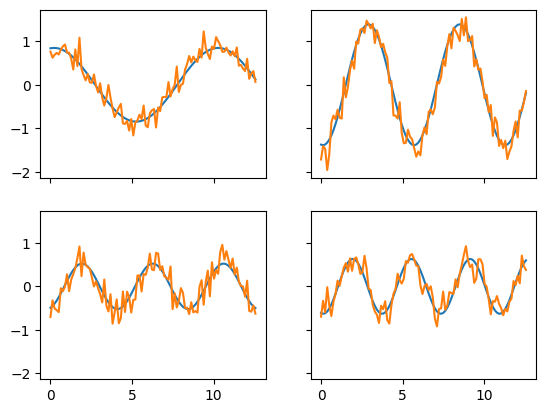

In [4]:
# plot clean vs noisy examples
fig, axes = plt.subplots(2, 2, sharex = True, sharey = True)
ax = axes[0,0]
ax.plot(t, clean_curve[0,:])
ax.plot(t, noisy_curve[0,:])

ax = axes[1,0]
ax.plot(t, clean_curve[1,:])
ax.plot(t, noisy_curve[1,:])

ax = axes[0,1]
ax.plot(t, clean_curve[2,:])
ax.plot(t, noisy_curve[2,:])

ax = axes[1,1]
ax.plot(t, clean_curve[3,:])
ax.plot(t, noisy_curve[3,:])

## Dataset Split

Split into **90% training / 10% validation**.
- **Input**  (noisy_curve) : X_train -> shape (9000, 100), X_val -> shape (1000, 100)
- **Target** (clean_curve): Y_train -> shape (9000, 100), Y_val -> shape (1000, 100)

In [ ]:
# dataset split
X_train = noisy_curve[:9000,:]
X_val = noisy_curve[9000:,:]
Y_train = clean_curve[:9000,:]
Y_val = clean_curve[9000:,:]

## Autoencoder Model

**Fully connected (dense) autoencoder**
- **Encoder** compresses the input into a low-dimensional **latent space**
- **Decoder** reconstructs the signal from the latent representation

The network is trained to minimise **mean squared error (MSE)** between the reconstructed and clean signal.

In [6]:
N = 100

autoencoder = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(16, activation='relu'),  # latent (bottleneck) layer
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,092 (58.95 KB)

 Trainable params: 15,092 (58.95 KB)

 Non-trainable params: 0 (0.00 B)

## Training with .fit()

.fit() trains the model. The key arguments are:

| Argument | What it means |
|---|---|
| X_train, Y_train | The data the model learns from |
| epochs | How many times the model sees the full training data |
| batch_size | How many samples to process before updating the weights |
| validation_data=(X_val, Y_val) | Data the model never trains on. It is used to check performance after each epoch |
| verbose=1 | Shows a progress bar while training; set to 0 to hide it |

After training, history stores the training loss and validation loss at every epoch:

If validation loss starts increasing while training loss keeps decreasing -> the model is **overfitting** (memorising the training data instead of generalising).

In [7]:
history = autoencoder.fit(
    X_train, Y_train,
    epochs=50,
    batch_size=128,
    validation_data=(X_val, Y_val),
    verbose=1
)

# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3859 - val_loss: 0.1622
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0765 - val_loss: 0.0396
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0264 - val_loss: 0.0179
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0157 - val_loss: 0.0142
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0127 - val_loss: 0.0115
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0104 - val_loss: 0.0095
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0089 - val_loss: 0.0083
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0079 - val_loss: 0.0075
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0071 - val_loss: 0.0068
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0066 - val_loss: 0.0064
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0061 - val_loss: 0.0059
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0058 - val_lo

Plot the training and validation loss curves.

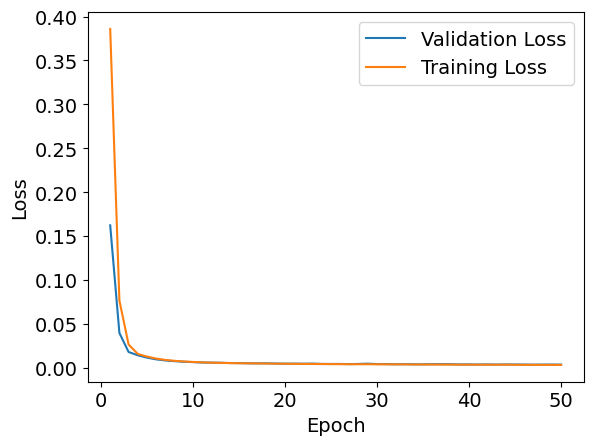

In [8]:
# plot loss curves
plt.rcParams['font.size'] = 14
plt.plot(epochs_range, val_loss, label = 'Validation Loss')
plt.plot(epochs_range, train_loss, label = 'Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

## Making Predictions with .predict()

model.predict(X) passes the input array through the trained network and returns reconstructed outputs.

In [9]:
examples = [0, 1, 2, 3]

reconstructed_Y = autoencoder.predict(X_val[examples]) # Returns shape (4, 100)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


Plot the clean signal, noisy input, and reconstructed signal.

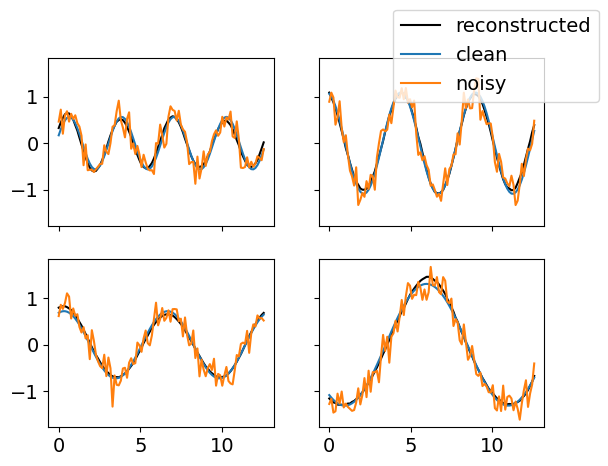

In [16]:
# Plot clean / noisy / reconstructed for each example
fig, axes = plt.subplots(2, 2, sharex = True, sharey = True)
ax = axes[0,0]
ax.plot(t, reconstructed_Y[0,:], label = 'reconstructed', c = 'k')
ax.plot(t, Y_val[0,:], label = 'clean')
ax.plot(t, X_val[0,:], label = 'noisy')

ax = axes[1,0]
ax.plot(t, reconstructed_Y[1,:], label = 'reconstructed', c = 'k')
ax.plot(t, Y_val[1,:], label = 'clean')
ax.plot(t, X_val[1,:], label = 'noisy')

ax = axes[0,1]
ax.plot(t, reconstructed_Y[2,:], label = 'reconstructed', c = 'k')
ax.plot(t, Y_val[2,:], label = 'clean')
ax.plot(t, X_val[2,:], label = 'noisy')

ax = axes[1,1]
ax.plot(t, reconstructed_Y[3,:], label = 'reconstructed', c = 'k')
ax.plot(t, Y_val[3,:], label = 'clean')
ax.plot(t, X_val[3,:], label = 'noisy')

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')

## Problem 3

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_42 (Dense)                │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,157 (51.39 KB)

 Trainable params: 13,157 (51.39 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5143 - val_loss: 0.4968
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4881 - val_loss: 0.4856
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4801 - val_loss: 0.4781
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4739 - val_loss: 0.4739
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4665 - val_loss: 0.4636
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4573 - val_loss: 0.4552
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4505 - val_loss: 0.4491
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4467 - val_loss: 0.4456
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4440 - val_loss: 0.4435
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4419 - val_loss: 0.4420
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4396 - val_loss: 0.4395
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4381 - val_lo

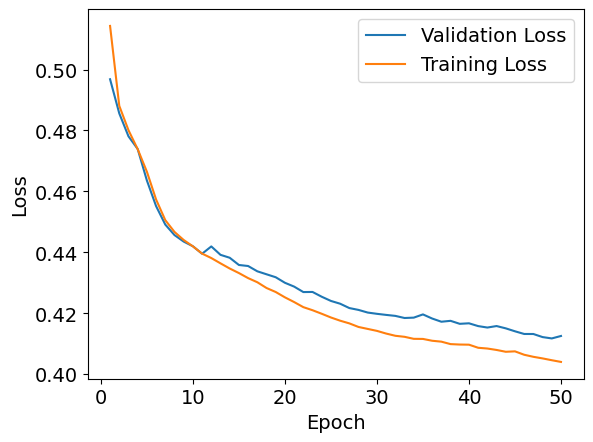

In [33]:
#making a cell containing all of the model building in problem 2 to make changing bits easier
# dataset split
X_train = noisy_curve[:9000,:]
X_val = noisy_curve[9000:,:]
Y_train = clean_curve[:9000,:]
Y_val = clean_curve[9000:,:]

#setup autoencoder
autoencoder = Sequential([
    Input(shape=(100,)),
    Dense(64, activation='relu'),
    Dense(1, activation='relu'),  # latent (bottleneck) layer
    Dense(64, activation='relu'),
    Dense(100,  activation='linear') # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()

history = autoencoder.fit(
    X_train, Y_train,
    epochs=50,
    batch_size=128,
    validation_data=(X_val, Y_val),
    verbose=1
)

# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

# plot loss curves
plt.rcParams['font.size'] = 14
plt.plot(epochs_range, val_loss, label = 'Validation Loss')
plt.plot(epochs_range, train_loss, label = 'Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


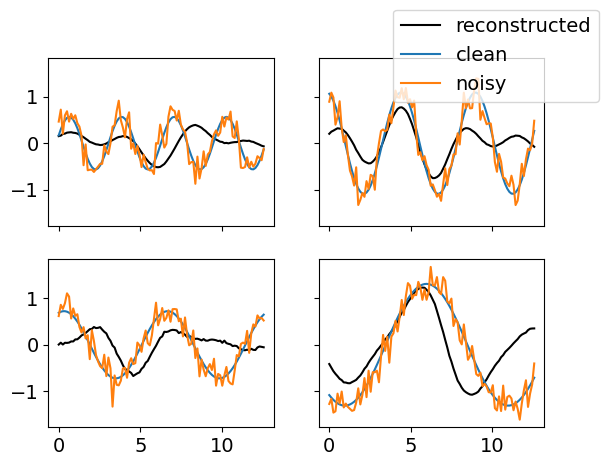

In [34]:
#test the autoencoder
examples = [0, 1, 2, 3]

reconstructed_Y = autoencoder.predict(X_val[examples]) 

# Plot clean / noisy / reconstructed for each example
fig, axes = plt.subplots(2, 2, sharex = True, sharey = True)
ax = axes[0,0]
ax.plot(t, reconstructed_Y[0,:], label = 'reconstructed', c = 'k')
ax.plot(t, Y_val[0,:], label = 'clean')
ax.plot(t, X_val[0,:], label = 'noisy')

ax = axes[1,0]
ax.plot(t, reconstructed_Y[1,:], label = 'reconstructed', c = 'k')
ax.plot(t, Y_val[1,:], label = 'clean')
ax.plot(t, X_val[1,:], label = 'noisy')

ax = axes[0,1]
ax.plot(t, reconstructed_Y[2,:], label = 'reconstructed', c = 'k')
ax.plot(t, Y_val[2,:], label = 'clean')
ax.plot(t, X_val[2,:], label = 'noisy')

ax = axes[1,1]
ax.plot(t, reconstructed_Y[3,:], label = 'reconstructed', c = 'k')
ax.plot(t, Y_val[3,:], label = 'clean')
ax.plot(t, X_val[3,:], label = 'noisy')

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')

## Problem 3d

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_50 (Dense)                │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,092 (58.95 KB)

 Trainable params: 15,092 (58.95 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5609 - val_loss: 0.4554
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3390 - val_loss: 0.2531
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2065 - val_loss: 0.1810
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1647 - val_loss: 0.1626
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1474 - val_loss: 0.1500
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1339 - val_loss: 0.1384
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1230 - val_loss: 0.1287
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1145 - val_loss: 0.1224
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1081 - val_loss: 0.1179
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1034 - val_loss: 0.1145
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0993 - val_loss: 0.1114
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0960 - val_lo

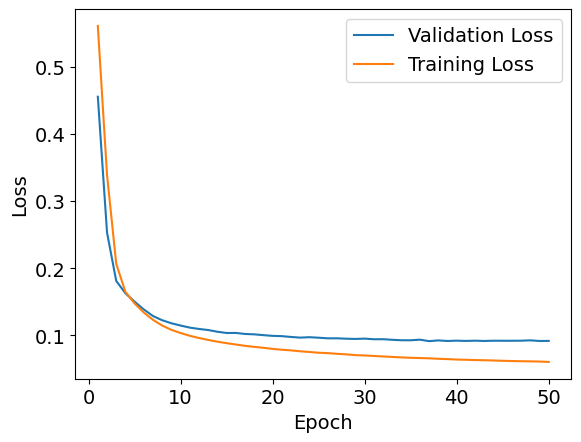

In [37]:
# change noise model to laplacian
epsilon = np.random.laplace(size = [10000, 100])
noisy_curve = clean_curve + epsilon

# dataset split
X_train = noisy_curve[:9000,:]
X_val = noisy_curve[9000:,:]
Y_train = clean_curve[:9000,:]
Y_val = clean_curve[9000:,:]

#setup autoencoder
autoencoder = Sequential([
    Input(shape=(100,)),
    Dense(64, activation='relu'),
    Dense(16, activation='relu'),  # latent (bottleneck) layer
    Dense(64, activation='relu'),
    Dense(100,  activation='linear') # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()

history = autoencoder.fit(
    X_train, Y_train,
    epochs=50,
    batch_size=128,
    validation_data=(X_val, Y_val),
    verbose=1
)

# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

# plot loss curves
plt.rcParams['font.size'] = 14
plt.plot(epochs_range, val_loss, label = 'Validation Loss')
plt.plot(epochs_range, train_loss, label = 'Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


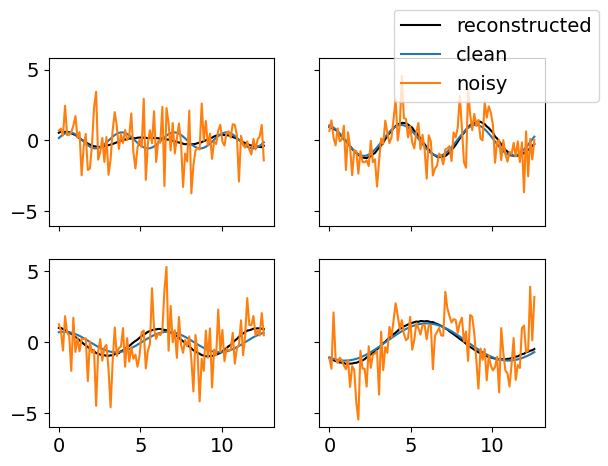

In [38]:
#test the autoencoder
examples = [0, 1, 2, 3]

reconstructed_Y = autoencoder.predict(X_val[examples]) 

# Plot clean / noisy / reconstructed for each example
fig, axes = plt.subplots(2, 2, sharex = True, sharey = True)
ax = axes[0,0]
ax.plot(t, reconstructed_Y[0,:], label = 'reconstructed', c = 'k')
ax.plot(t, Y_val[0,:], label = 'clean')
ax.plot(t, X_val[0,:], label = 'noisy')

ax = axes[1,0]
ax.plot(t, reconstructed_Y[1,:], label = 'reconstructed', c = 'k')
ax.plot(t, Y_val[1,:], label = 'clean')
ax.plot(t, X_val[1,:], label = 'noisy')

ax = axes[0,1]
ax.plot(t, reconstructed_Y[2,:], label = 'reconstructed', c = 'k')
ax.plot(t, Y_val[2,:], label = 'clean')
ax.plot(t, X_val[2,:], label = 'noisy')

ax = axes[1,1]
ax.plot(t, reconstructed_Y[3,:], label = 'reconstructed', c = 'k')
ax.plot(t, Y_val[3,:], label = 'clean')
ax.plot(t, X_val[3,:], label = 'noisy')

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')